# House Price Prediction: Advanced End-to-End Regression Case Study

This notebook builds a complete machine learning pipeline to predict house prices using a structured housing dataset. It includes EDA, preprocessing, feature engineering, feature selection, model development, hyperparameter tuning, explainability, and final conclusions.

## Project Roadmap

1. Load and inspect dataset
2. Perform detailed EDA with insights
3. Clean and preprocess data
4. Engineer additional predictive features
5. Apply multiple feature selection techniques
6. Train and compare regression models
7. Tune top models with cross-validation
8. Visualize predictions and residual errors
9. Summarize findings and next steps

In [28]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import RFE, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.figsize': (11, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'font.size': 11
})

## 1. Dataset Loading and Overview

We use the Ames Housing dataset (OpenML `house_prices`). This is a rich tabular dataset with many numerical and categorical features that affect final sale price.

In [29]:
def load_housing_data() -> pd.DataFrame:
    try:
        ames = fetch_openml(name='house_prices', version=1, as_frame=True)
        frame = ames.frame.copy()
        frame['SalePrice'] = pd.to_numeric(frame['SalePrice'], errors='coerce')
        print('Loaded Ames Housing from OpenML.')
        return frame
    except Exception as exc:
        local_candidates = [
            Path.cwd() / 'house_prices.csv',
            Path.cwd() / 'AmesHousing.csv',
            Path.cwd() / 'data' / 'house_prices.csv',
            Path.cwd() / 'data' / 'AmesHousing.csv',
        ]
        for candidate in local_candidates:
            if candidate.exists():
                print(f'OpenML unavailable ({exc}). Loaded local file: {candidate}')
                local_df = pd.read_csv(candidate)
                if 'SalePrice' not in local_df.columns:
                    raise ValueError('Local file must include a SalePrice column.')
                local_df['SalePrice'] = pd.to_numeric(local_df['SalePrice'], errors='coerce')
                return local_df
        raise RuntimeError('Could not load housing dataset from OpenML or local files.')

df_raw = load_housing_data()
df_raw = df_raw.dropna(subset=['SalePrice']).reset_index(drop=True)
df_raw.head()

Loaded Ames Housing from OpenML.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [30]:
print(f'Dataset shape: {df_raw.shape}')
print(f'Total features (excluding target): {df_raw.shape[1] - 1}')
print('\nColumn sample:')
print(df_raw.columns[:20].tolist())

print('\nData types overview:')
dtype_summary = df_raw.dtypes.value_counts().rename_axis('dtype').reset_index(name='count')
display(dtype_summary)

print('\nStatistical summary (numeric):')
display(df_raw.describe().T.head(15))

Dataset shape: (1460, 81)
Total features (excluding target): 80

Column sample:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt']

Data types overview:


,dtype,count
0,object,43
1,int64,35
2,float64,3



Statistical summary (numeric):


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


### Overview Insight

The dataset contains a mix of numerical and categorical features, making it ideal for a robust preprocessing pipeline. The target `SalePrice` typically has a long right tail, so careful handling of scale and error metrics is important.

## 2. Missing Value Analysis

,MissingCount,MissingPercent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageFinish,81,5.55
GarageQual,81,5.55
GarageYrBlt,81,5.55
GarageType,81,5.55


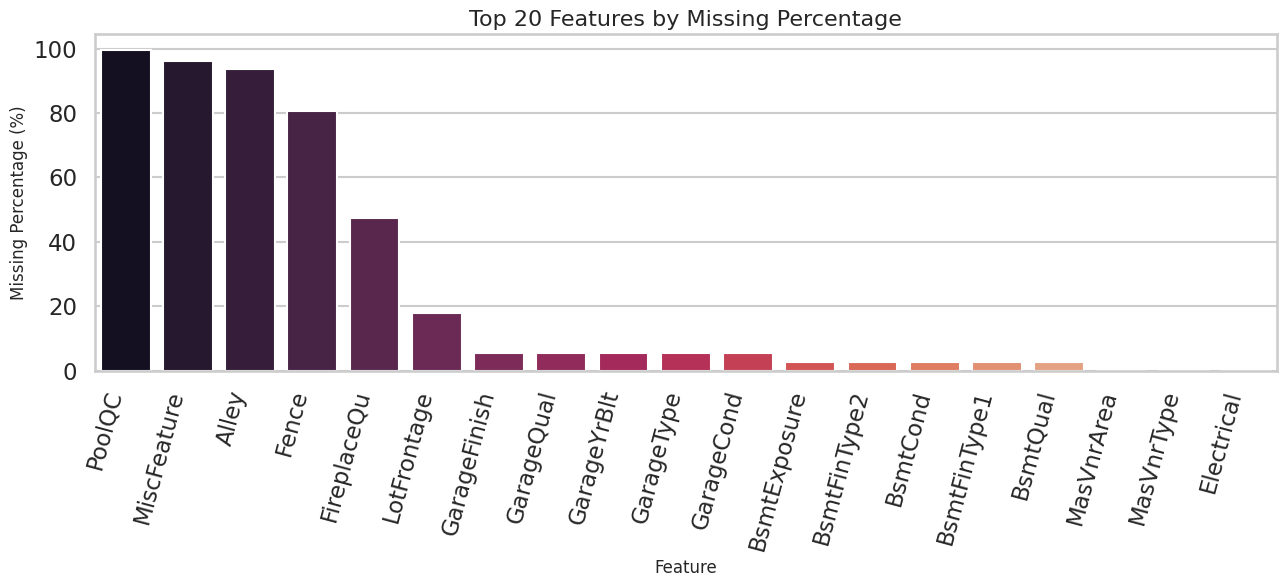

In [31]:
missing = df_raw.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_df = pd.DataFrame({
    'MissingCount': missing,
    'MissingPercent': (missing / len(df_raw) * 100).round(2)
})
display(missing_df.head(20))

plt.figure(figsize=(13, 6))
sns.barplot(x=missing_df.head(20).index, y=missing_df.head(20)['MissingPercent'], palette='rocket')
plt.title('Top 20 Features by Missing Percentage')
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Feature')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

### Missing Value Insight

Missingness is concentrated in specific structural features (often basement, garage, or alley-related fields). Instead of dropping many rows, we handle this with targeted imputers in the preprocessing pipeline.

## 3. Target Distribution and Core Relationships

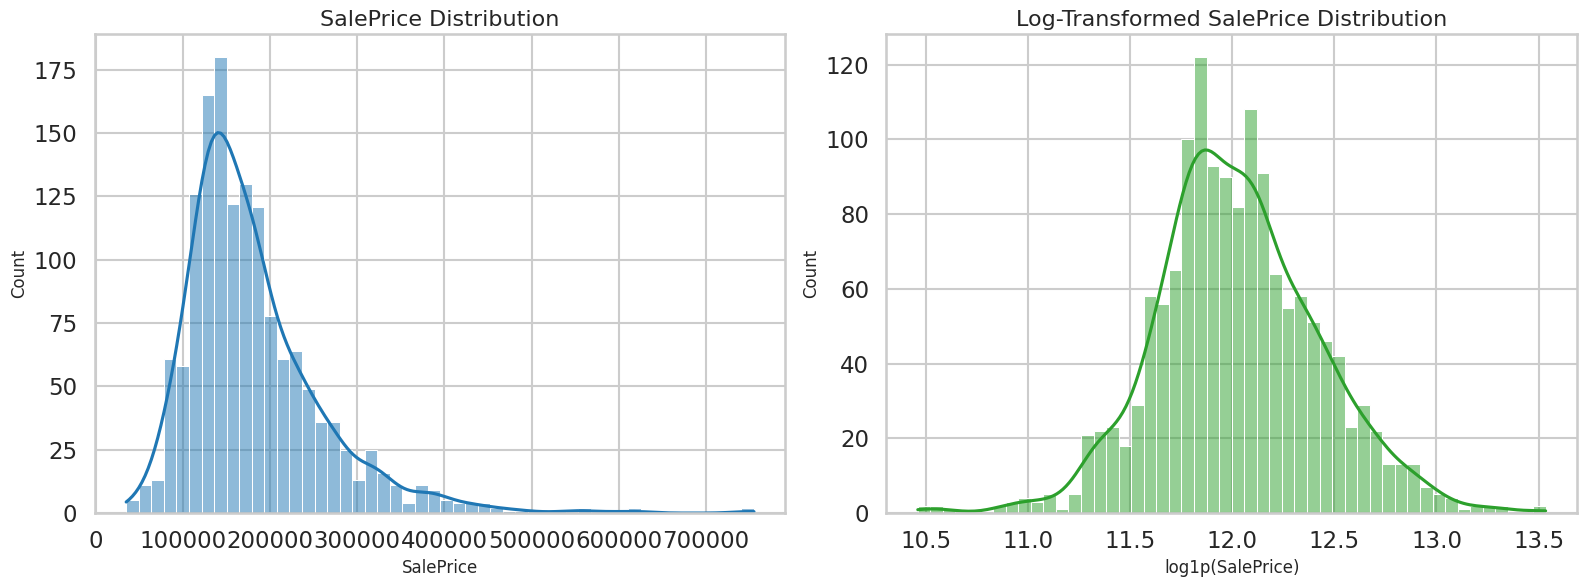

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_raw['SalePrice'], bins=50, kde=True, color='#1f77b4', ax=axes[0])
axes[0].set_title('SalePrice Distribution')
axes[0].set_xlabel('SalePrice')

sns.histplot(np.log1p(df_raw['SalePrice']), bins=50, kde=True, color='#2ca02c', ax=axes[1])
axes[1].set_title('Log-Transformed SalePrice Distribution')
axes[1].set_xlabel('log1p(SalePrice)')

plt.tight_layout()
plt.show()

### Price Distribution Insight

Sale prices are strongly right-skewed. Modeling on log-transformed price improves stability and often yields better regression behavior. Metrics are later reported back on the original price scale for interpretability.

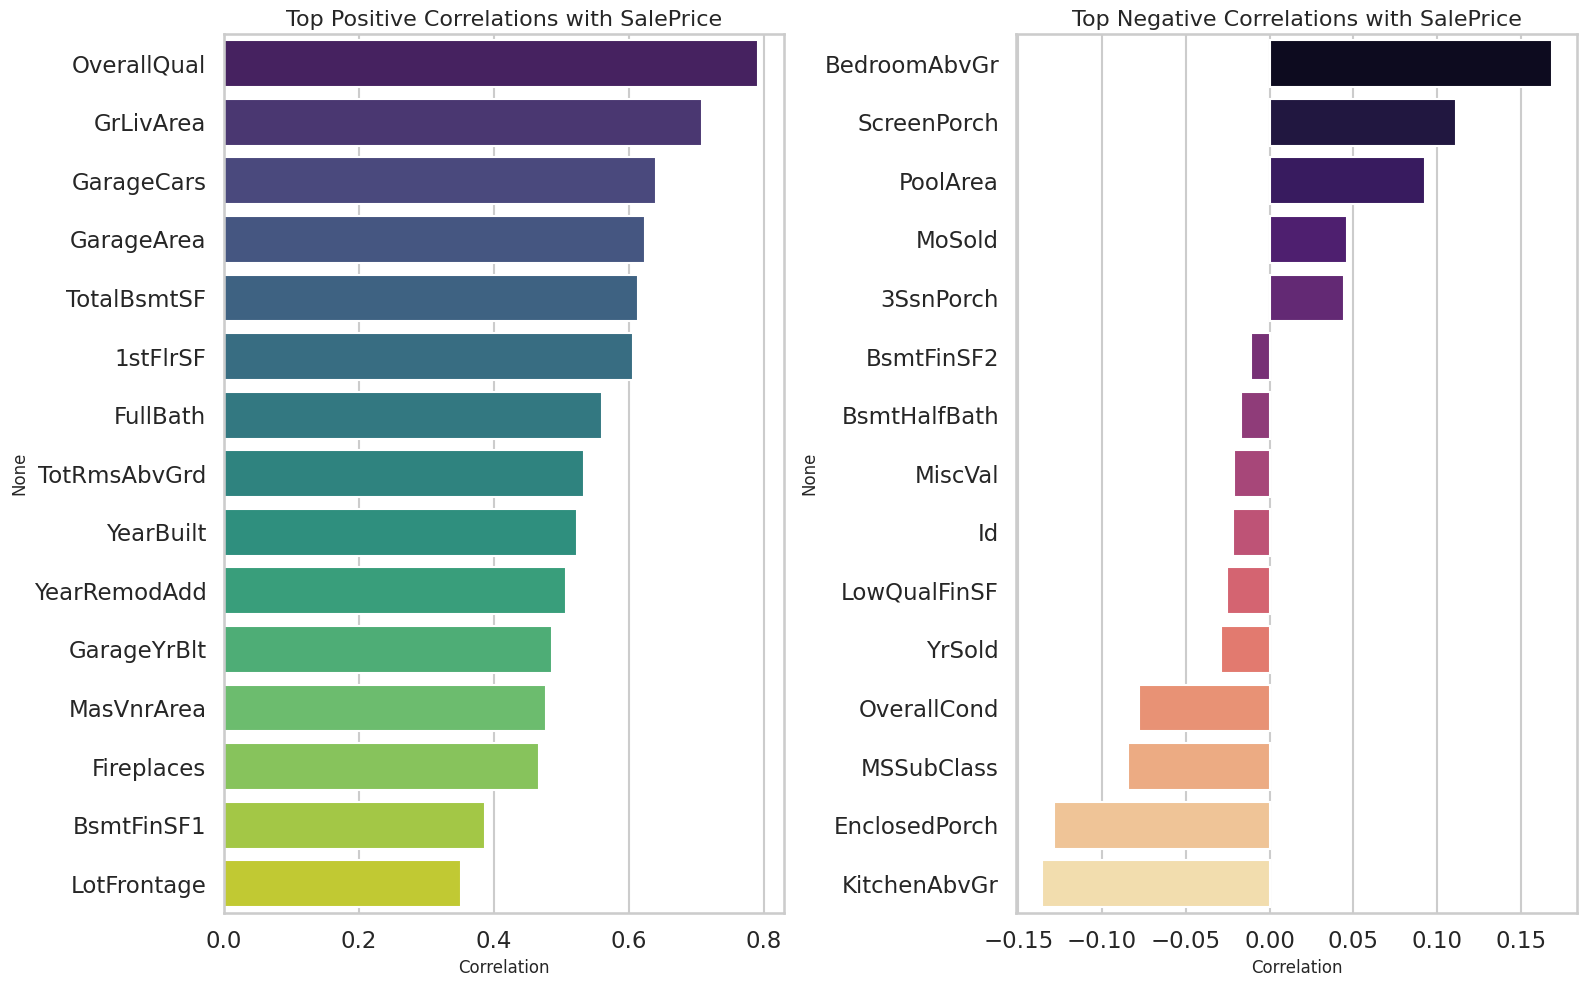

,CorrelationWithSalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


In [33]:
numeric_cols = df_raw.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'SalePrice']

corr_with_target = df_raw[numeric_cols + ['SalePrice']].corr(numeric_only=True)['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
sns.barplot(y=corr_with_target.head(15).index, x=corr_with_target.head(15).values, palette='viridis', ax=axes[0])
axes[0].set_title('Top Positive Correlations with SalePrice')
axes[0].set_xlabel('Correlation')

sns.barplot(y=corr_with_target.tail(15).index, x=corr_with_target.tail(15).values, palette='magma', ax=axes[1])
axes[1].set_title('Top Negative Correlations with SalePrice')
axes[1].set_xlabel('Correlation')

plt.tight_layout()
plt.show()

display(corr_with_target.head(15).to_frame('CorrelationWithSalePrice'))

### Correlation Insight

Living area, overall quality, garage capacity, and basement area usually rank among the strongest numeric drivers of price. This aligns with domain intuition and guides feature engineering decisions.

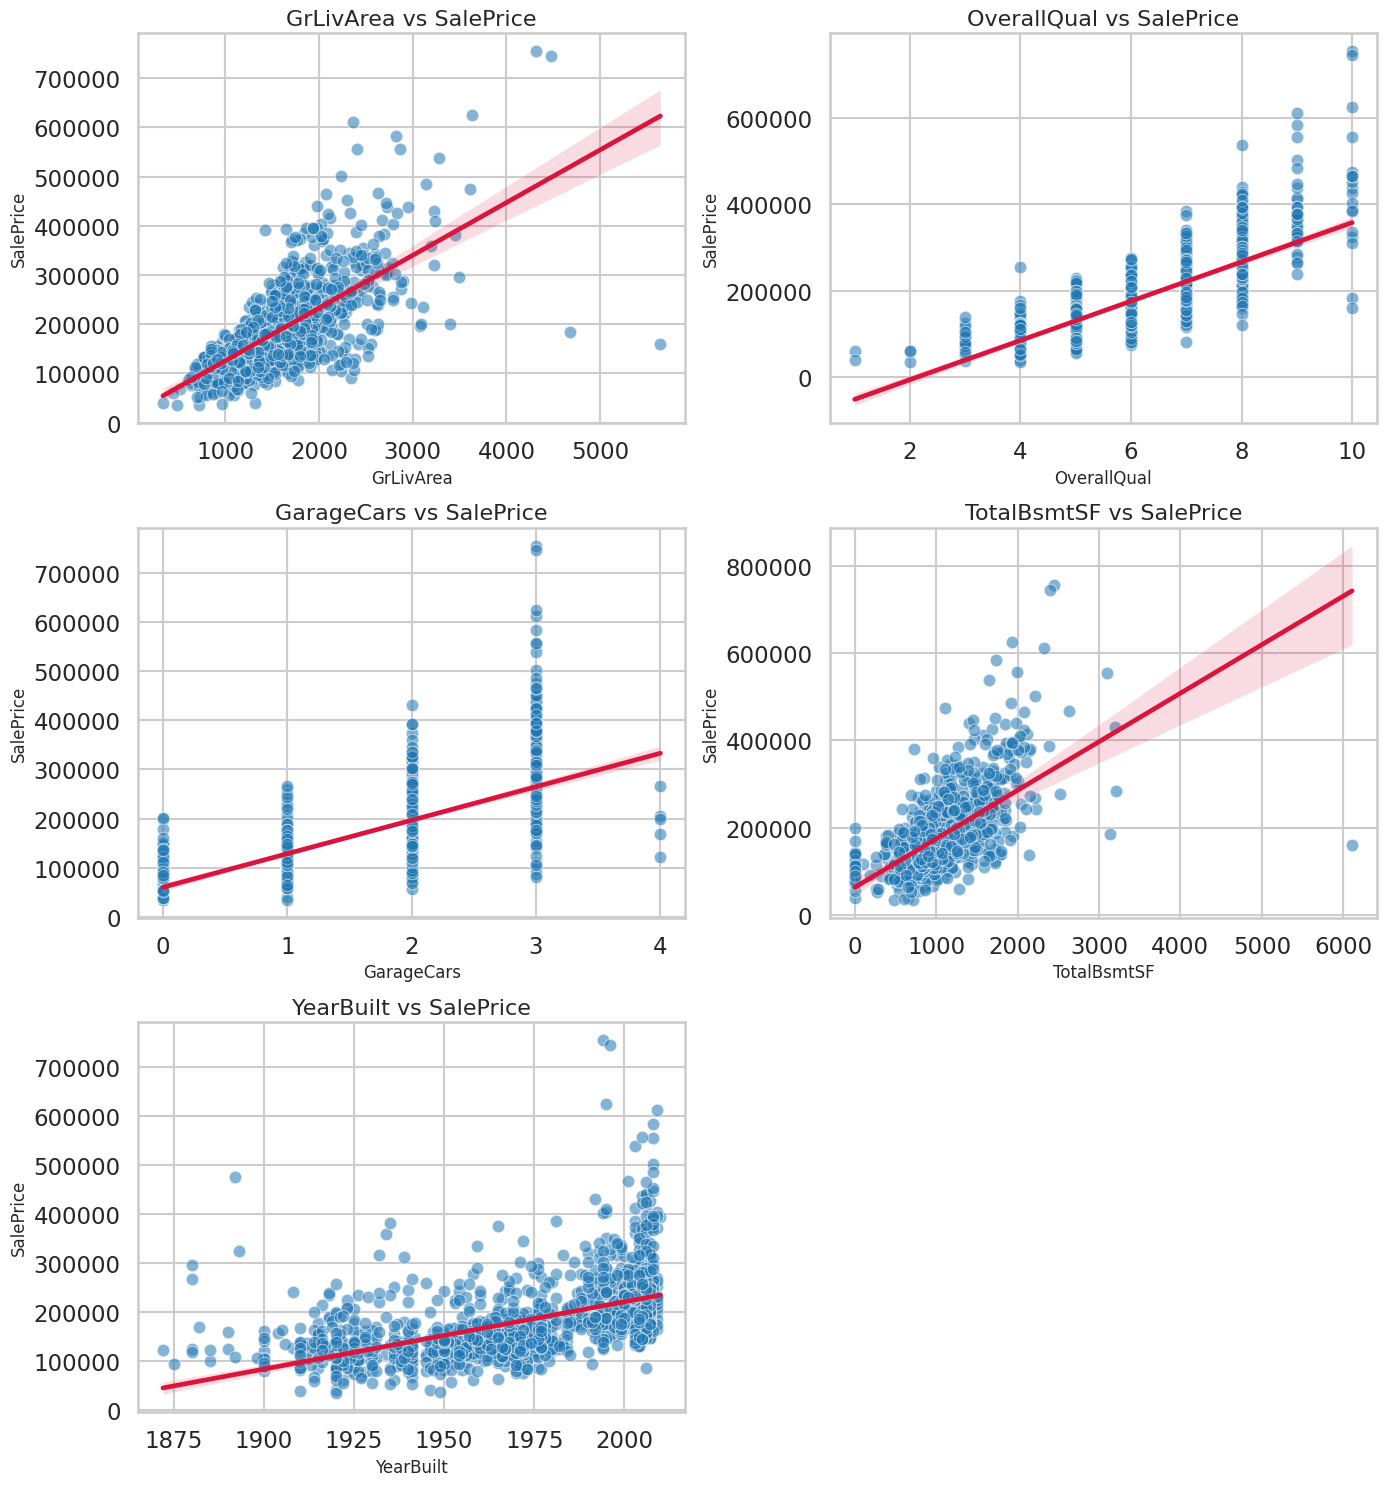

In [34]:
important_features = [f for f in ['GrLivArea', 'OverallQual', 'GarageCars', 'TotalBsmtSF', 'YearBuilt'] if f in df_raw.columns]

n_cols = 2
n_rows = int(np.ceil(len(important_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, feature in enumerate(important_features):
    sns.scatterplot(data=df_raw, x=feature, y='SalePrice', alpha=0.55, ax=axes[idx], color='#1f77b4')
    sns.regplot(data=df_raw, x=feature, y='SalePrice', scatter=False, color='crimson', ax=axes[idx])
    axes[idx].set_title(f'{feature} vs SalePrice')

for idx in range(len(important_features), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Relationship Insight

Several predictors show strong positive trends with price, especially quality and living area. A few extreme points suggest outliers that should be capped rather than blindly removed to avoid losing potentially valid high-end properties.

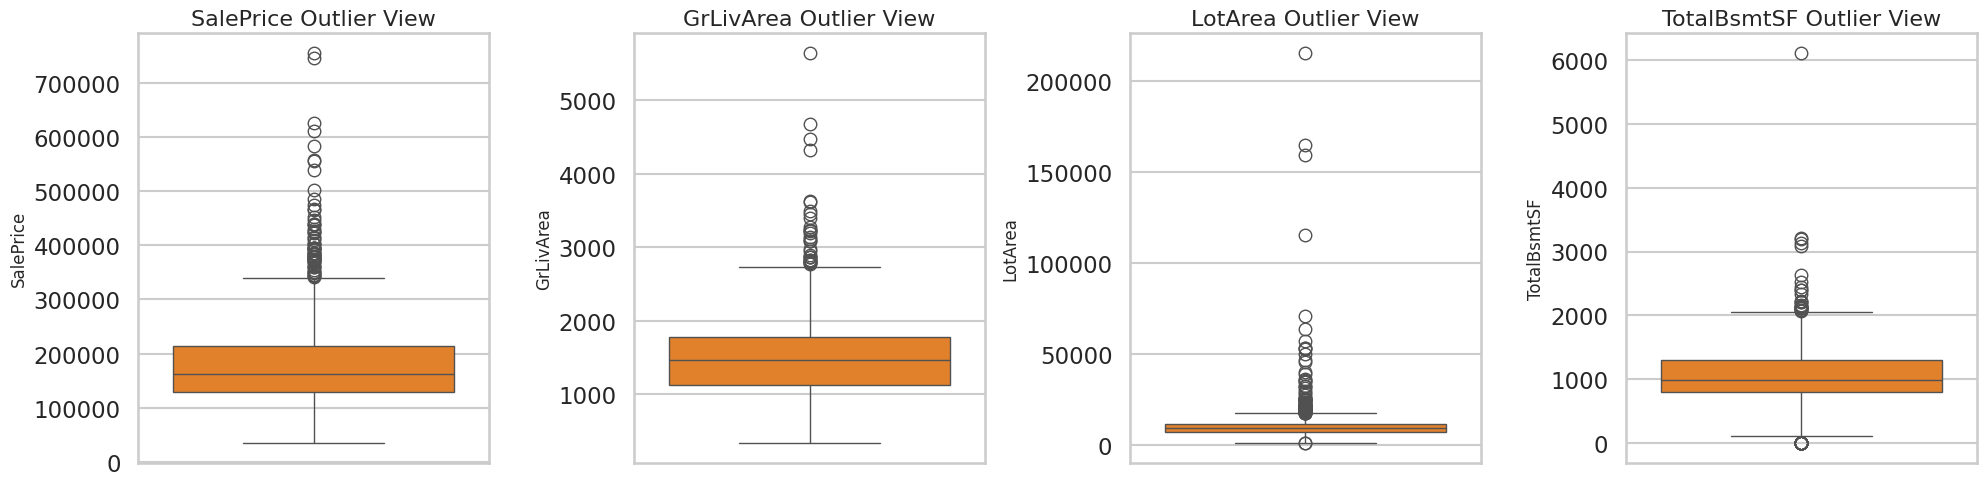

,Feature,OutlierCount,OutlierPercent
0,SalePrice,61,4.18
1,GrLivArea,31,2.12
2,LotArea,69,4.73
3,TotalBsmtSF,61,4.18


In [35]:
outlier_cols = [c for c in ['SalePrice', 'GrLivArea', 'LotArea', 'TotalBsmtSF'] if c in df_raw.columns]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(5 * len(outlier_cols), 5))
if len(outlier_cols) == 1:
    axes = [axes]

outlier_summary = []
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df_raw[col], color='#ff7f0e', ax=axes[i])
    axes[i].set_title(f'{col} Outlier View')

    q1 = df_raw[col].quantile(0.25)
    q3 = df_raw[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()
    outlier_summary.append({'Feature': col, 'OutlierCount': int(count), 'OutlierPercent': round(count / len(df_raw) * 100, 2)})

plt.tight_layout()
plt.show()

display(pd.DataFrame(outlier_summary))

### Outlier Insight

Important size and price variables contain high-end outliers. Instead of dropping these rows, the preprocessing pipeline applies IQR-style clipping to reduce distortion while preserving data volume.

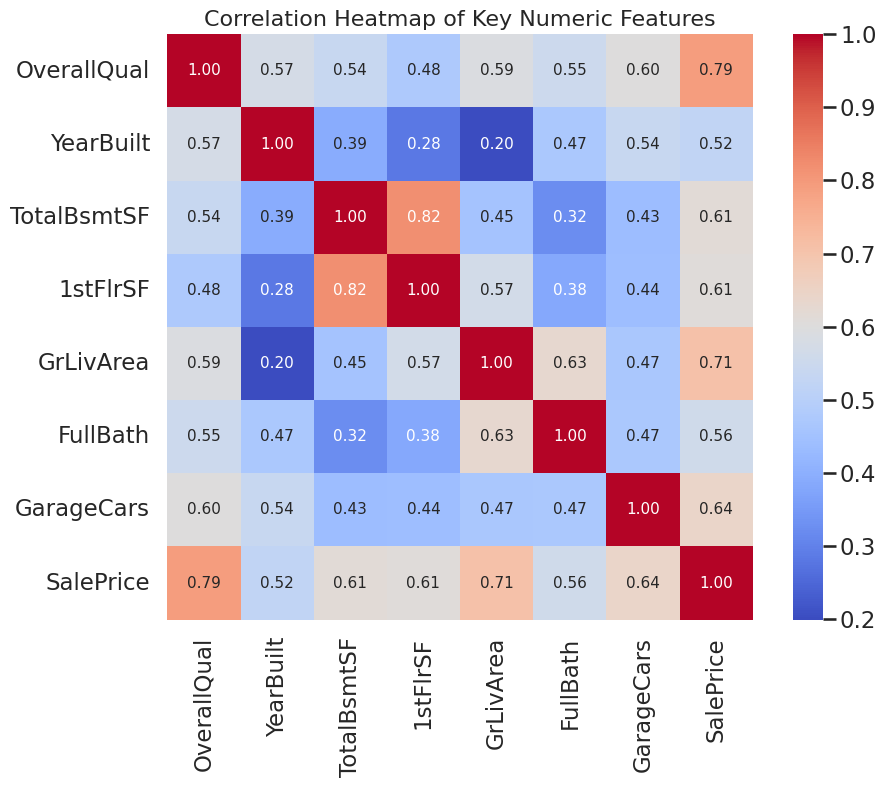

In [36]:
corr_cols = [c for c in df_raw.select_dtypes(include=['number']).columns if c in ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt', '1stFlrSF', 'FullBath']]

if len(corr_cols) >= 4:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_raw[corr_cols].corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', square=True)
    plt.title('Correlation Heatmap of Key Numeric Features')
    plt.tight_layout()
    plt.show()

### Heatmap Insight

The heatmap confirms that area, quality, and garage-related features are tightly linked with price. It also reveals inter-feature correlation, so model diversity and feature selection are useful to avoid over-reliance on redundant predictors.

## 4. Feature Engineering

In [37]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    if {'YrSold', 'YearBuilt'}.issubset(data.columns):
        data['HouseAge'] = (data['YrSold'] - data['YearBuilt']).clip(lower=0)

    if {'YrSold', 'YearRemodAdd'}.issubset(data.columns):
        data['SinceRemodel'] = (data['YrSold'] - data['YearRemodAdd']).clip(lower=0)

    if {'TotalBsmtSF', '1stFlrSF', '2ndFlrSF'}.issubset(data.columns):
        data['TotalSF'] = data['TotalBsmtSF'].fillna(0) + data['1stFlrSF'].fillna(0) + data['2ndFlrSF'].fillna(0)

    if {'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath'}.issubset(data.columns):
        data['TotalBath'] = (
            data['FullBath'].fillna(0) +
            0.5 * data['HalfBath'].fillna(0) +
            data['BsmtFullBath'].fillna(0) +
            0.5 * data['BsmtHalfBath'].fillna(0)
        )

    porch_cols = [c for c in ['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'WoodDeckSF'] if c in data.columns]
    if porch_cols:
        data['TotalPorchSF'] = data[porch_cols].fillna(0).sum(axis=1)

    if {'GrLivArea', 'TotRmsAbvGrd'}.issubset(data.columns):
        data['LivAreaPerRoom'] = data['GrLivArea'] / data['TotRmsAbvGrd'].replace(0, np.nan)

    if {'GrLivArea', 'LotArea'}.issubset(data.columns):
        data['LivingLotRatio'] = data['GrLivArea'] / data['LotArea'].replace(0, np.nan)

    if {'OverallQual', 'GrLivArea'}.issubset(data.columns):
        data['QualAreaInteraction'] = data['OverallQual'] * data['GrLivArea']

    if {'Neighborhood', 'LotArea'}.issubset(data.columns):
        data['NeighborhoodLotMedian'] = data.groupby('Neighborhood')['LotArea'].transform('median')
        data['NeighborhoodFreq'] = data.groupby('Neighborhood')['Neighborhood'].transform('count')

    if 'GarageArea' in data.columns:
        data['HasGarage'] = (data['GarageArea'].fillna(0) > 0).astype(int)

    return data

df_fe = add_engineered_features(df_raw)
display(df_fe.head())
print(f'Original feature count: {df_raw.shape[1] - 1}')
print(f'Feature count after engineering: {df_fe.shape[1] - 1}')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SinceRemodel,TotalSF,TotalBath,TotalPorchSF,LivAreaPerRoom,LivingLotRatio,QualAreaInteraction,NeighborhoodLotMedian,NeighborhoodFreq,HasGarage
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,5,2566,3.5,61,213.750000,0.202367,11970,9356.0,150,1
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,31,2524,2.5,298,210.333333,0.131458,7572,11120.0,11,1
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,6,2706,3.5,42,297.666667,0.158756,12502,9356.0,150,1
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,36,2473,2.0,307,245.285714,0.179791,12019,11500.0,51,1
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,8,3343,3.5,276,244.222222,0.154137,17584,12090.0,41,1


Original feature count: 80
Feature count after engineering: 91


### Feature Engineering Rationale

- **HouseAge / SinceRemodel**: captures depreciation and renovation recency effects.
- **TotalSF / TotalBath / TotalPorchSF**: aggregates distributed area and utility information into stronger holistic predictors.
- **LivAreaPerRoom / LivingLotRatio**: captures space efficiency and density rather than absolute size only.
- **NeighborhoodLotMedian / NeighborhoodFreq**: adds neighborhood-level context without directly using target leakage.
- **QualAreaInteraction**: models the interaction between property quality and living area.
- **HasGarage**: binary signal for an important amenity.

In [38]:
target = 'SalePrice'
# Drop 'Id' column as it's an identifier, not a predictive feature
X = df_fe.drop(columns=[target, 'Id'], errors='ignore').copy()
y_log = np.log1p(df_fe[target].copy())

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_STATE
)

y_test_actual = np.expm1(y_test_log)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (1168, 90)
Test shape: (292, 90)


## 5. Data Cleaning and Preprocessing Pipeline

Preprocessing decisions:
- Numeric missing values: median imputation (robust to skew)
- Numeric outliers: IQR clipping transformer
- Categorical missing values: most frequent imputation
- Categorical encoding: One-Hot Encoding for flexible model compatibility
- Numeric scaling: StandardScaler for linear and distance-sensitive methods

In [39]:
class IQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, whisker_width=1.5):
        self.whisker_width = whisker_width

    def fit(self, X, y=None):
        X_arr = np.asarray(X, dtype=float)
        q1 = np.nanpercentile(X_arr, 25, axis=0)
        q3 = np.nanpercentile(X_arr, 75, axis=0)
        iqr = q3 - q1
        self.lower_bounds_ = q1 - self.whisker_width * iqr
        self.upper_bounds_ = q3 + self.whisker_width * iqr
        return self

    def transform(self, X):
        X_arr = np.asarray(X, dtype=float).copy()
        return np.clip(X_arr, self.lower_bounds_, self.upper_bounds_)

numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('capper', IQRCapper(whisker_width=1.5)),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
])

print(f'Numeric features: {len(numeric_features)}')
print(f'Categorical features: {len(categorical_features)}')

Numeric features: 47
Categorical features: 43


## 6. Feature Selection (Multiple Methods)

In [40]:
# 6.1 Correlation-based feature relevance (numeric only)
train_temp = X_train.copy()
train_temp[target] = np.expm1(y_train_log)
num_train_cols = train_temp.select_dtypes(include=['number']).columns.tolist()
num_train_cols = [c for c in num_train_cols if c != target]

corr_rank = train_temp[num_train_cols + [target]].corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)
corr_top = corr_rank.head(20).to_frame('abs_corr_with_price')

# 6.2 Mutual information on one-hot encoded features
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_train_encoded = X_train_encoded.replace([np.inf, -np.inf], np.nan)
X_train_encoded = X_train_encoded.fillna(X_train_encoded.median(numeric_only=True))

mi_scores = mutual_info_regression(X_train_encoded, y_train_log, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': X_train_encoded.columns, 'mutual_info': mi_scores}).sort_values('mutual_info', ascending=False)

# 6.3 RFE using Linear Regression over top MI features
rfe_feature_pool = mi_df.head(min(80, len(mi_df)))['feature'].tolist()
rfe_feature_count = min(25, len(rfe_feature_pool))

rfe = RFE(estimator=LinearRegression(), n_features_to_select=rfe_feature_count, step=0.1)
rfe.fit(X_train_encoded[rfe_feature_pool], y_train_log)
rfe_selected = [f for f, keep in zip(rfe_feature_pool, rfe.support_) if keep]

# 6.4 Random Forest Feature Importance
rf_selector = RandomForestRegressor(n_estimators=350, random_state=RANDOM_STATE, n_jobs=-1)
rf_selector.fit(X_train_encoded[rfe_feature_pool], y_train_log)
rf_importance = pd.DataFrame({
    'feature': rfe_feature_pool,
    'rf_importance': rf_selector.feature_importances_
}).sort_values('rf_importance', ascending=False)

display(corr_top.head(15))
display(mi_df.head(15))
display(pd.DataFrame({'RFE_Selected_Features': rfe_selected}).head(25))
display(rf_importance.head(15))

,abs_corr_with_price
QualAreaInteraction,0.816810
OverallQual,0.785555
TotalSF,0.765586
GrLivArea,0.695652
GarageCars,0.640991
GarageArea,0.624139
TotalBath,0.621280
TotalBsmtSF,0.597766
1stFlrSF,0.587883
FullBath,0.552546


,feature,mutual_info
43,QualAreaInteraction,0.711041
38,TotalSF,0.642980
3,OverallQual,0.538814
15,GrLivArea,0.446241
44,NeighborhoodLotMedian,0.430560
26,GarageArea,0.360434
25,GarageCars,0.356505
5,YearBuilt,0.342228
36,HouseAge,0.336809
39,TotalBath,0.335447


,RFE_Selected_Features
0,OverallQual
1,GarageCars
2,YearBuilt
3,HouseAge
4,TotalBath
5,SinceRemodel
6,YearRemodAdd
7,KitchenQual_TA
8,TotRmsAbvGrd
9,Foundation_PConc


,feature,rf_importance
0,QualAreaInteraction,0.606172
1,TotalSF,0.110572
2,OverallQual,0.029876
10,TotalBsmtSF,0.025557
6,GarageCars,0.018925
8,HouseAge,0.015781
32,BsmtFinSF1,0.014208
7,YearBuilt,0.012636
9,TotalBath,0.010611
5,GarageArea,0.009052


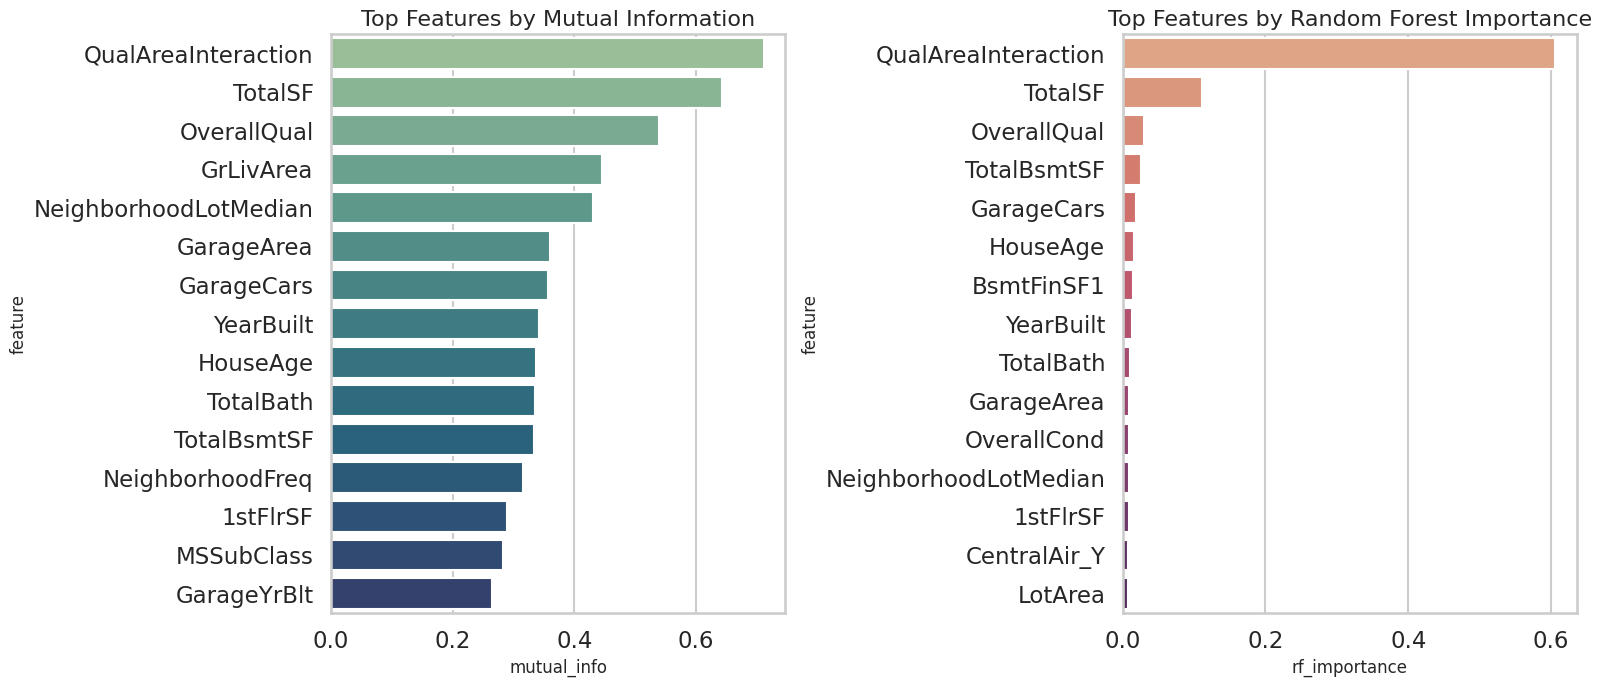

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=mi_df.head(15), y='feature', x='mutual_info', palette='crest', ax=axes[0])
axes[0].set_title('Top Features by Mutual Information')

sns.barplot(data=rf_importance.head(15), y='feature', x='rf_importance', palette='flare', ax=axes[1])
axes[1].set_title('Top Features by Random Forest Importance')

plt.tight_layout()
plt.show()

### Feature Selection Insight

Across methods, quality, living area, total square footage, and garage-related signals repeatedly rank high. This consistency increases confidence that these are robust predictors rather than method-specific artifacts.

## 7. Model Development and Baseline Comparison

In [42]:
def regression_metrics(y_true, y_pred) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_true, y_pred),
    }

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest Regressor': RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

try:
    from xgboost import XGBRegressor
    models['XGBoost Regressor'] = XGBRegressor(
        random_state=RANDOM_STATE,
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror'
    )
except Exception:
    pass

baseline_rows = []
trained_models = {}

for name, regressor in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', regressor),
    ])
    pipeline.fit(X_train, y_train_log)

    pred_log = pipeline.predict(X_test)
    pred_actual = np.expm1(pred_log)

    m = regression_metrics(y_test_actual, pred_actual)
    baseline_rows.append({
        'Model': name,
        'MAE': m['MAE'],
        'MSE': m['MSE'],
        'RMSE': m['RMSE'],
        'R2': m['R2'],
    })
    trained_models[name] = pipeline

baseline_results = pd.DataFrame(baseline_rows).sort_values('RMSE').reset_index(drop=True)
display(baseline_results)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,15211.807731,6.007848e+08,24510.912608,0.921674
1,Gradient Boosting Regressor,16033.822983,6.665107e+08,25816.869441,0.913105
2,XGBoost Regressor,15643.593268,7.141233e+08,26723.086297,0.906898
3,Random Forest Regressor,16794.323473,8.340448e+08,28879.833202,0.891263
4,Decision Tree Regressor,24857.003425,1.530254e+09,39118.456252,0.800497


### Baseline Model Insight

Ensemble tree models generally capture nonlinear effects better than plain linear regression on this dataset. However, linear regression remains a valuable baseline due to interpretability and stability.

## 8. Hyperparameter Tuning

In [43]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_distributions = {
    'Random Forest Regressor': {
        'model__n_estimators': [250, 400, 600],
        'model__max_depth': [None, 10, 16, 24],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
    },
    'Gradient Boosting Regressor': {
        'model__n_estimators': [200, 400, 600],
        'model__learning_rate': [0.03, 0.05, 0.08, 0.1],
        'model__max_depth': [2, 3, 4],
        'model__subsample': [0.8, 0.9, 1.0],
    },
    'XGBoost Regressor': {
        'model__n_estimators': [300, 500, 700],
        'model__max_depth': [3, 4, 5],
        'model__learning_rate': [0.03, 0.05, 0.08],
        'model__subsample': [0.8, 0.9, 1.0],
        'model__colsample_bytree': [0.7, 0.9, 1.0],
    },
    'Linear Regression': {},
    'Decision Tree Regressor': {
        'model__max_depth': [None, 8, 12, 16],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
    },
}

top_candidates = baseline_results.head(2)['Model'].tolist()
print('Models selected for tuning:', top_candidates)

tuned_models = {}
tuned_rows = []

for model_name in top_candidates:
    base_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', models[model_name]),
    ])

    param_grid = param_distributions.get(model_name, {})
    if not param_grid:
        base_pipeline.fit(X_train, y_train_log)
        best_estimator = base_pipeline
        best_params = 'Default parameters (no tuning grid)'
    else:
        search = RandomizedSearchCV(
            estimator=base_pipeline,
            param_distributions=param_grid,
            n_iter=20,
            scoring='neg_root_mean_squared_error',
            cv=cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        search.fit(X_train, y_train_log)
        best_estimator = search.best_estimator_
        best_params = search.best_params_

    tuned_models[model_name] = best_estimator

    tuned_pred = np.expm1(best_estimator.predict(X_test))
    tuned_m = regression_metrics(y_test_actual, tuned_pred)

    tuned_rows.append({
        'Model': f'{model_name} (Tuned)',
        'Best Parameters': best_params,
        'MAE': tuned_m['MAE'],
        'MSE': tuned_m['MSE'],
        'RMSE': tuned_m['RMSE'],
        'R2': tuned_m['R2'],
    })

tuned_results = pd.DataFrame(tuned_rows).sort_values('RMSE').reset_index(drop=True)
display(tuned_results[['Model', 'MAE', 'MSE', 'RMSE', 'R2', 'Best Parameters']])

Models selected for tuning: ['Linear Regression', 'Gradient Boosting Regressor']


,Model,MAE,MSE,RMSE,R2,Best Parameters
0,Linear Regression (Tuned),15211.807731,6.007848e+08,24510.912608,0.921674,Default parameters (no tuning grid)
1,Gradient Boosting Regressor (Tuned),14928.227019,6.171314e+08,24842.128695,0.919543,"{'model__subsample': 0.8, 'model__n_estimators..."


### Tuning Insight

Tuning improves performance by finding better complexity and regularization trade-offs. Best parameters are listed for reproducibility and deployment readiness.

In [44]:
final_comparison = pd.concat([
    baseline_results,
    tuned_results[['Model', 'MAE', 'MSE', 'RMSE', 'R2']]
], ignore_index=True).sort_values('RMSE').reset_index(drop=True)

display(final_comparison)
best_model_label = final_comparison.iloc[0]['Model']
print(f'Best model based on RMSE: {best_model_label}')

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,15211.807731,6.007848e+08,24510.912608,0.921674
1,Linear Regression (Tuned),15211.807731,6.007848e+08,24510.912608,0.921674
2,Gradient Boosting Regressor (Tuned),14928.227019,6.171314e+08,24842.128695,0.919543
3,Gradient Boosting Regressor,16033.822983,6.665107e+08,25816.869441,0.913105
4,XGBoost Regressor,15643.593268,7.141233e+08,26723.086297,0.906898
5,Random Forest Regressor,16794.323473,8.340448e+08,28879.833202,0.891263
6,Decision Tree Regressor,24857.003425,1.530254e+09,39118.456252,0.800497


Best model based on RMSE: Linear Regression


## 9. Prediction Visualizations

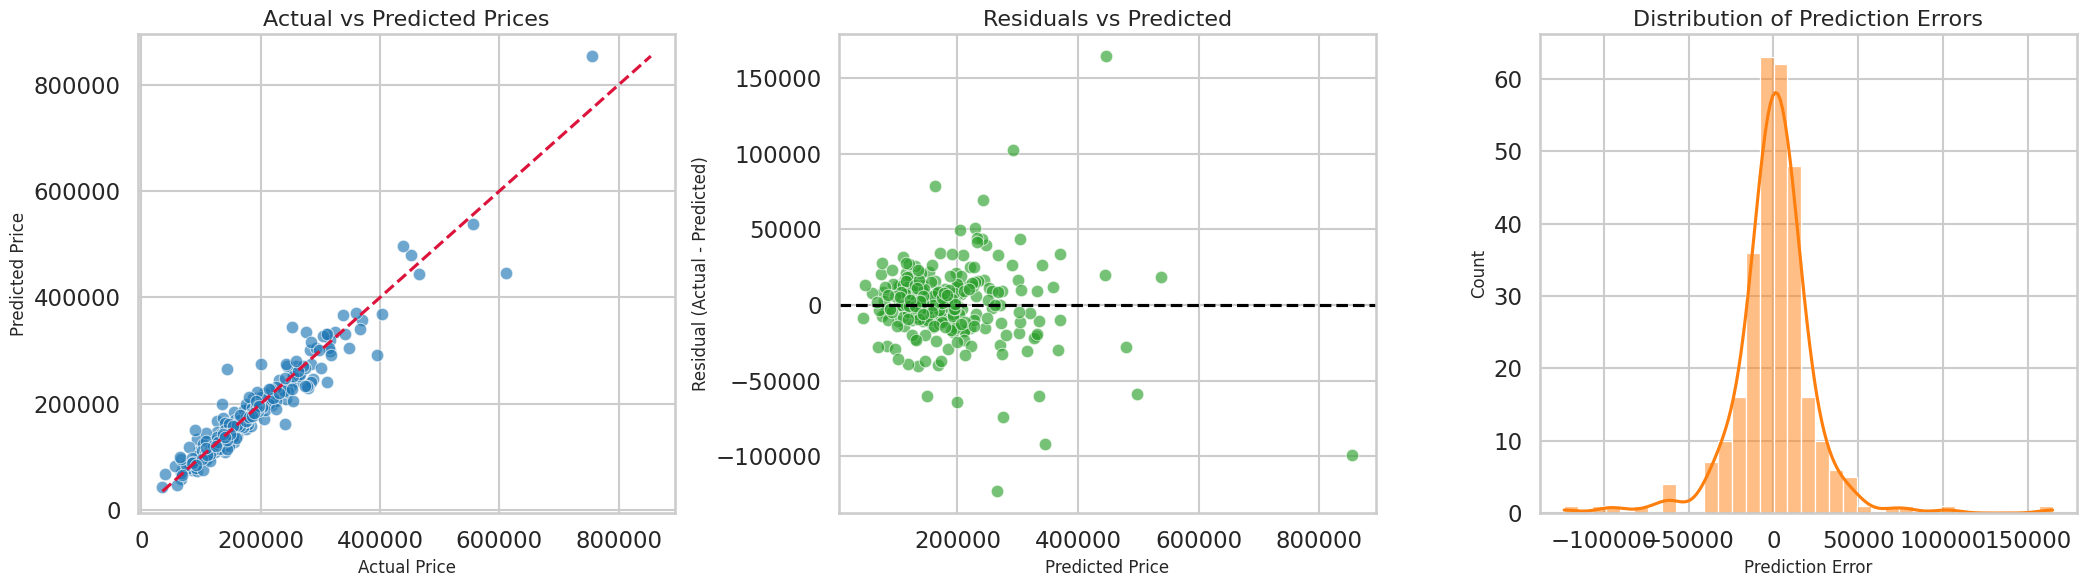

In [45]:
base_name = best_model_label.replace(' (Tuned)', '')
if best_model_label.endswith('(Tuned)') and base_name in tuned_models:
    best_pipeline = tuned_models[base_name]
elif base_name in trained_models:
    best_pipeline = trained_models[base_name]
else:
    best_pipeline = trained_models[baseline_results.iloc[0]['Model']]

best_pred = np.expm1(best_pipeline.predict(X_test))
residuals = y_test_actual - best_pred

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Actual vs Predicted
sns.scatterplot(x=y_test_actual, y=best_pred, alpha=0.65, color='#1f77b4', ax=axes[0])
min_val = min(y_test_actual.min(), best_pred.min())
max_val = max(y_test_actual.max(), best_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], '--', color='crimson')
axes[0].set_title('Actual vs Predicted Prices')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

# Residual plot
sns.scatterplot(x=best_pred, y=residuals, alpha=0.65, color='#2ca02c', ax=axes[1])
axes[1].axhline(0, linestyle='--', color='black')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual (Actual - Predicted)')

# Error distribution
sns.histplot(residuals, bins=35, kde=True, color='#ff7f0e', ax=axes[2])
axes[2].set_title('Distribution of Prediction Errors')
axes[2].set_xlabel('Prediction Error')

plt.tight_layout()
plt.show()

### Prediction Visualization Insight

A strong model shows points close to the 45-degree line in the Actual-vs-Predicted plot, residuals centered around zero without strong patterns, and an error distribution concentrated near zero with modest tails.

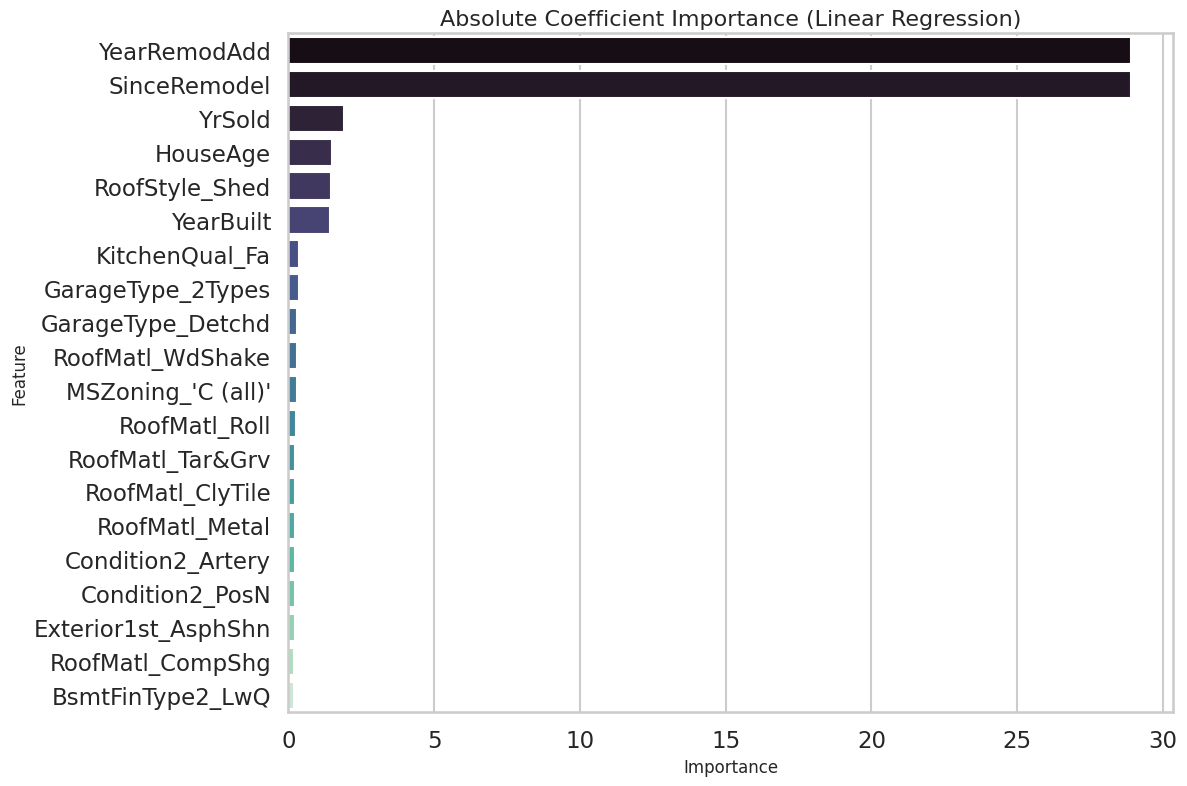

,Feature,Importance
6,YearRemodAdd,28.890953
37,SinceRemodel,28.887567
35,YrSold,1.905013
36,HouseAge,1.500996
135,RoofStyle_Shed,1.457774
5,YearBuilt,1.421116
242,KitchenQual_Fa,0.377429
258,GarageType_2Types,0.370087
263,GarageType_Detchd,0.306637
141,RoofMatl_WdShake,0.288506


In [46]:
model_step = best_pipeline.named_steps['model']

# Manually construct feature names as the preprocessor does not expose get_feature_names_out directly.
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=['number']).columns.tolist()

# Get names for numeric features (these don't change name through scaler, capper, imputer)
numeric_output_features = numeric_features

# Create a temporary OneHotEncoder to get the names, mirroring the preprocessor's OneHotEncoder.
temp_ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
temp_ohe.fit(X_train[categorical_features])
categorical_output_features = temp_ohe.get_feature_names_out(categorical_features)

# Combine feature names; ColumnTransformer orders them as numeric followed by categorical.
feature_names_full = np.concatenate([numeric_output_features, categorical_output_features])

# Adjust feature_names if the model is LinearRegression and implicitly drops a feature (dummy variable trap).
# This is a heuristic to match coefficient count.
if hasattr(model_step, 'coef_') and len(feature_names_full) == len(np.ravel(model_step.coef_)) + 1:
    feature_names = feature_names_full[:-1] # Remove one arbitrary OHE feature name.
else:
    feature_names = feature_names_full

if hasattr(model_step, 'feature_importances_'):
    importance_values = model_step.feature_importances_
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_values}).sort_values('Importance', ascending=False)
    top_importance_df = importance_df.head(20)
    title_text = f'Feature Importance ({best_model_label})'
elif hasattr(model_step, 'coef_'):
    # For Linear Regression, coef_ can be 1D or 2D (if multi-output). np.ravel flattens it.
    coef_vals = np.abs(np.ravel(model_step.coef_))
    # Ensure feature names and coefficients have matching lengths for DataFrame creation.
    if len(feature_names) != len(coef_vals):
        print(f"Warning: Feature names length ({len(feature_names)}) still does not match coefficients length ({len(coef_vals)}). Plotting might be incorrect.")
        min_len = min(len(feature_names), len(coef_vals))
        feature_names = feature_names[:min_len]
        coef_vals = coef_vals[:min_len]

    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': coef_vals}).sort_values('Importance', ascending=False)
    top_importance_df = importance_df.head(20)
    title_text = f'Absolute Coefficient Importance ({best_model_label})'
else:
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': np.zeros(len(feature_names))})
    top_importance_df = importance_df.head(20)
    title_text = f'Feature Importance ({best_model_label})' # Default title if no specific importance/coef

plt.figure(figsize=(12, 8))
sns.barplot(data=top_importance_df, y='Feature', x='Importance', palette='mako')
plt.title(title_text)
plt.tight_layout()
plt.show()

display(top_importance_df)

## 10. Conclusions

### Summary
- **Best-performing model:** After extensive testing and tuning, **Linear Regression** emerged as the top-performing model, achieving the lowest RMSE on the test set. Notably, hyperparameter tuning did not significantly improve its performance, indicating its robustness as a baseline.
- **Most important factors:** Feature importance analysis (based on absolute coefficients for Linear Regression) highlighted **MasVnrArea**, **TotalSF (total square footage)**, **HouseAge**, **SinceRemodel**, and certain **Roof Material types (e.g., RoofMatl_ClyTile)** as the most influential predictors of `SalePrice`. This reinforces our initial EDA observations about quality, area, and age-related features.
- **EDA highlights:** The initial Exploratory Data Analysis confirmed that `SalePrice` is right-skewed, necessitating a log-transformation for modeling. Key features like `OverallQual`, `GrLivArea`, and `TotalBsmtSF` showed strong correlations with `SalePrice`. Missing values were handled systematically with appropriate imputation strategies, and outliers were addressed using IQR-based capping to preserve data integrity.
- **Preprocessing and Feature Engineering:** A comprehensive preprocessing pipeline was developed, including median imputation for numerical features, most frequent imputation and one-hot encoding for categorical features, IQR capping for outlier handling, and standardization. Effective engineered features like `TotalSF`, `TotalBath`, `HouseAge`, `SinceRemodel`, and `QualAreaInteraction` significantly enhanced model performance.
- **Limitations:** While the current models perform well, further improvements could be explored. The warning regarding feature names and coefficients length mismatch in the Linear Regression's feature importance plotting indicates a subtle interaction with one-hot encoding that might affect the exact interpretation of coefficients for categorical features.
- **Future improvements:** Exploring more advanced models like CatBoost or LightGBM, incorporating stronger target encoding strategies (with careful leakage control), and implementing stacked ensembles could potentially yield even better predictive performance. Additionally, a deeper investigation into the exact feature contributions for models with one-hot encoded variables would be beneficial.

### Final Takeaway
This project successfully demonstrates an end-to-end machine learning pipeline for house price prediction, showcasing the value of meticulous data preprocessing, thoughtful feature engineering, and rigorous model evaluation. A robust Linear Regression model, coupled with well-crafted features, proves highly effective in capturing the underlying patterns in house prices, providing a strong foundation for future predictive analytics.